# Portfolio Construction and Failed Validation

## Crypto Alpha Across Horizons

This notebook consolidates the original portfolio-construction, turnover/execution-cost, and 2023–2024 validation stages.

The purpose is deliberately sequential:

1. reconstruct the four **training-frozen** signal candidates;
2. convert them into dollar-neutral, gross-one portfolios with the original holding rules;
3. evaluate exact subsequent returns, full-L1 turnover, and 7/20/40-bps execution costs;
4. determine which implementations earn the right to enter validation;
5. apply the frozen 2023–2024 validation protocol to the surviving momentum candidates;
6. preserve the validation failure rather than rescuing the strategy.

The later continuation redesign is **not** part of this notebook. The notebook ends where the original research cycle failed.

### Research firewall

The training implementation ends before 2023. Validation uses data only through 2024-12-31 20:00 UTC. No 2025+ return is used anywhere in this notebook.

In [1]:
from pathlib import Path
from collections import deque
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def locate_project_root():
    env_root = os.getenv("CRYPTO_ALPHA_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / "data").is_dir():
            return candidate

    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd / "crypto-alpha-research",
        cwd.parent / "crypto-alpha-research",
    ]
    for candidate in candidates:
        if (candidate / "data").is_dir() and (
            (candidate / "notebooks").is_dir()
            or (candidate / "public_notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. Set CRYPTO_ALPHA_ROOT "
        "to the crypto-alpha-research folder."
    )


PROJECT_ROOT = locate_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
UNIVERSE_DIR = PROJECT_ROOT / "data" / "universe"

BAR_SIZE = pd.Timedelta(hours=4)
TRAIN_START = pd.Timestamp("2020-04-01 00:00:00", tz="UTC")
TRAIN_FORMATION_END = pd.Timestamp("2022-12-25 00:00:00", tz="UTC")
VALIDATION_START = pd.Timestamp("2023-01-01 00:00:00", tz="UTC")
VALIDATION_FORMATION_END_EXCLUSIVE = pd.Timestamp("2024-12-25 00:00:00", tz="UTC")
VALIDATION_ACCOUNTING_END = pd.Timestamp("2024-12-31 20:00:00", tz="UTC")
FINAL_TEST_START = pd.Timestamp("2025-01-01 00:00:00", tz="UTC")

MIN_ASSETS = 20
MOMENTUM_DELAY = pd.Timedelta(days=1)
PERIODS_PER_YEAR = 365 * 6
PRIMARY_COST_BPS = 20
COST_BPS_CASES = [7, 20, 40]
WEIGHT_TOL = 1e-14

CANDIDATE_SPECS = {
    "reversal_baseline": {
        "family": "reversal",
        "holding_period": pd.Timedelta(hours=4),
        "holding_bars": 1,
    },
    "reversal_activity": {
        "family": "reversal",
        "holding_period": pd.Timedelta(hours=4),
        "holding_bars": 1,
    },
    "momentum_immediate": {
        "family": "momentum",
        "holding_period": pd.Timedelta(days=7),
        "holding_bars": 42,
    },
    "momentum_delayed_1d": {
        "family": "momentum",
        "holding_period": pd.Timedelta(days=6),
        "holding_bars": 36,
    },
}

DISPLAY_NAMES = {
    "reversal_baseline": "Baseline reversal",
    "reversal_activity": "Activity reversal",
    "momentum_immediate": "Immediate momentum",
    "momentum_delayed_1d": "1d-delayed momentum",
}


def month_start(timestamp):
    return pd.Timestamp(
        year=timestamp.year,
        month=timestamp.month,
        day=1,
        tz="UTC",
    )


def centered_rank(series):
    return series.rank(method="average", pct=True) - 0.5


def exact_endpoint_return(prices, delta):
    past = prices.reindex(prices.index - delta).copy()
    past.index = prices.index
    return prices / past - 1.0


def annualized_sharpe(returns, periods_per_year=PERIODS_PER_YEAR):
    x = pd.Series(returns).dropna().astype(float)
    if len(x) < 2:
        return np.nan
    sigma = x.std(ddof=1)
    if not np.isfinite(sigma) or sigma <= 0:
        return np.nan
    return float(x.mean() / sigma * np.sqrt(periods_per_year))


def compounded_return(returns):
    x = pd.Series(returns).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    return float((1.0 + x).prod() - 1.0)


def break_even_bps(gross_returns, turnover):
    gross = pd.Series(gross_returns).astype(float)
    to = pd.Series(turnover).astype(float)
    valid = gross.notna() & to.notna()
    total_turnover = to.loc[valid].sum()
    if total_turnover <= 0:
        return np.nan
    return float(gross.loc[valid].sum() / total_turnover * 1e4)


# Frozen point-in-time universe.
csv_path = UNIVERSE_DIR / "research_monthly_universe.csv"
parquet_path = UNIVERSE_DIR / "research_monthly_universe.parquet"
if csv_path.exists():
    universe = pd.read_csv(csv_path)
elif parquet_path.exists():
    universe = pd.read_parquet(parquet_path)
else:
    raise FileNotFoundError("Missing frozen research monthly universe.")

universe["effective_month"] = pd.to_datetime(universe["effective_month"], utc=True)
universe = universe.sort_values(["effective_month", "symbol"]).reset_index(drop=True)

research_symbols = sorted(universe["symbol"].unique())
membership_by_month = {
    month: tuple(group["symbol"])
    for month, group in universe.groupby("effective_month")
}

assert universe["effective_month"].nunique() == 76
assert len(research_symbols) == 151
assert universe.groupby("effective_month")["symbol"].nunique().eq(25).all()

# Training/runoff load: admit data only through the exact endpoint needed to close the final training cohort.
close_series = []
quote_volume_series = []
shortened_series = []

for symbol in research_symbols:
    path = PROCESSED_DIR / f"{symbol}_4h.parquet"
    if not path.exists():
        raise FileNotFoundError(f"Missing required processed file: {path}")

    df = pd.read_parquet(
        path,
        columns=["open_time", "close_time", "close", "quote_volume"],
    ).copy()

    df["open_time"] = pd.to_datetime(df["open_time"], utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], utc=True)
    df["timestamp"] = df["open_time"] + BAR_SIZE
    df = (
        df.loc[df["timestamp"] <= VALIDATION_START]
        .drop_duplicates("timestamp")
        .sort_values("timestamp")
    )

    duration_minutes = (df["close_time"] - df["open_time"]).dt.total_seconds() / 60
    shortened = duration_minutes < 239

    close_series.append(
        df.set_index("timestamp")["close"].astype(float).rename(symbol)
    )

    qv = df.set_index("timestamp")["quote_volume"].astype(float).rename(symbol)
    short = pd.Series(shortened.to_numpy(), index=df["timestamp"], name=symbol)
    qv = qv.mask(short).where(qv > 0)

    quote_volume_series.append(qv)
    shortened_series.append(short.astype(bool))

close_panel = (
    pd.concat(close_series, axis=1)
    .sort_index()
    .reindex(columns=research_symbols)
)
quote_volume = (
    pd.concat(quote_volume_series, axis=1)
    .sort_index()
    .reindex(columns=research_symbols)
)

assert close_panel.index.max() <= VALIDATION_START

print("Project root:", PROJECT_ROOT)
print("Latest training/runoff timestamp admitted:", close_panel.index.max())
print("Validation-period data admitted in training section:", bool(close_panel.index.max() > VALIDATION_START))
print("2025+ admitted in training section:", bool(close_panel.index.max() >= FINAL_TEST_START))
print("Research universe:", len(research_symbols), "symbols; 25 assets/month")

Project root: /Users/owensimon/crypto-alpha-research
Latest training/runoff timestamp admitted: 2023-01-01 00:00:00+00:00
Validation-period data admitted in training section: False
2025+ admitted in training section: False
Research universe: 151 symbols; 25 assets/month


## 1. Reconstruct the four frozen training candidates

The candidate definitions are unchanged from the signal-research notebook:

- **REV:** immediate 4h reversal;
- **REVACT:** immediate 4h reversal conditioned by abnormal quote activity;
- **MOM:** immediate 3-day momentum;
- **MOMD:** the exact one-day-old MOM signal vintage.

The portfolio stage does not search for new signals. It takes these definitions as fixed inputs.

In [2]:
training_times = close_panel.index[
    (close_panel.index >= TRAIN_START)
    & (close_panel.index <= TRAIN_FORMATION_END)
]
training_times = pd.DatetimeIndex(
    [t for t in training_times if month_start(t) in membership_by_month]
)
assert len(training_times) == 5989

return_4h = exact_endpoint_return(close_panel, pd.Timedelta(hours=4))
return_3d = exact_endpoint_return(close_panel, pd.Timedelta(days=3))

# Abnormal quote activity: current log quote volume relative to the prior 180 4h bars.
log_quote_volume = np.log(quote_volume)
prior = log_quote_volume.shift(1)
rolling_mean = prior.rolling(window=180, min_periods=2).mean()
rolling_std = prior.rolling(window=180, min_periods=2).std(ddof=1)
quote_activity_z = ((log_quote_volume - rolling_mean) / rolling_std).where(rolling_std > 0)

candidate_panels = {
    name: pd.DataFrame(
        np.nan,
        index=training_times,
        columns=research_symbols,
        dtype=float,
    )
    for name in CANDIDATE_SPECS
}
price_rank_3d = pd.DataFrame(
    np.nan,
    index=training_times,
    columns=research_symbols,
    dtype=float,
)

for t in training_times:
    members = list(membership_by_month[month_start(t)])

    p4_raw = return_4h.loc[t, members].dropna()
    if len(p4_raw) >= MIN_ASSETS:
        p4 = centered_rank(p4_raw)
        candidate_panels["reversal_baseline"].loc[t, p4.index] = -p4.values

    rev_joint = pd.concat(
        [
            return_4h.loc[t, members].rename("price"),
            quote_activity_z.loc[t, members].rename("activity"),
        ],
        axis=1,
    ).dropna()

    if len(rev_joint) >= MIN_ASSETS:
        p4_joint = centered_rank(rev_joint["price"])
        a4 = centered_rank(rev_joint["activity"])
        revact = -p4_joint * (1.0 - a4)
        candidate_panels["reversal_activity"].loc[t, revact.index] = revact.values

    p3_raw = return_3d.loc[t, members].dropna()
    if len(p3_raw) >= MIN_ASSETS:
        p3 = centered_rank(p3_raw)
        price_rank_3d.loc[t, p3.index] = p3.values
        candidate_panels["momentum_immediate"].loc[t, p3.index] = p3.values

for t in training_times:
    source_t = t - MOMENTUM_DELAY
    if source_t not in price_rank_3d.index:
        continue

    current_members = list(membership_by_month[month_start(t)])
    delayed = price_rank_3d.loc[source_t, current_members].dropna()

    if len(delayed) >= MIN_ASSETS:
        candidate_panels["momentum_delayed_1d"].loc[t, delayed.index] = delayed.values

expected_usable = {
    "reversal_baseline": 5989,
    "reversal_activity": 5981,
    "momentum_immediate": 5989,
    "momentum_delayed_1d": 5935,
}

coverage_rows = []
for candidate, panel in candidate_panels.items():
    counts = panel.notna().sum(axis=1)
    usable = counts >= MIN_ASSETS
    actual = int(usable.sum())
    assert actual == expected_usable[candidate]

    coverage_rows.append(
        {
            "candidate": candidate,
            "usable_signal_timestamps": actual,
            "first_usable": panel.index[usable].min(),
            "last_usable": panel.index[usable].max(),
            "median_valid_assets": float(counts.loc[usable].median()),
        }
    )

candidate_coverage = pd.DataFrame(coverage_rows)

# Exact old-vintage check for MOMD.
max_vintage_diff = 0.0
n_vintage_checks = 0
for t, delayed_row in candidate_panels["momentum_delayed_1d"].iterrows():
    valid = delayed_row.notna()
    if not valid.any():
        continue
    source_t = t - MOMENTUM_DELAY
    source_row = price_rank_3d.loc[source_t]
    diff = (delayed_row.loc[valid] - source_row.loc[valid]).abs()
    max_vintage_diff = max(max_vintage_diff, float(diff.max()))
    n_vintage_checks += len(diff)

assert n_vintage_checks > 0
assert max_vintage_diff < 1e-12

display(candidate_coverage)
print("Maximum MOMD vintage difference:", f"{max_vintage_diff:.3e}")
print("Frozen candidate reconstruction: PASS")

,candidate,usable_signal_timestamps,first_usable,last_usable,median_valid_assets
0,reversal_baseline,5989,2020-04-01 00:00:00+00:00,2022-12-25 00:00:00+00:00,25.0
1,reversal_activity,5981,2020-04-01 00:00:00+00:00,2022-12-25 00:00:00+00:00,25.0
2,momentum_immediate,5989,2020-04-01 00:00:00+00:00,2022-12-25 00:00:00+00:00,25.0
3,momentum_delayed_1d,5935,2020-04-02 00:00:00+00:00,2022-12-25 00:00:00+00:00,25.0


Maximum MOMD vintage difference: 0.000e+00
Frozen candidate reconstruction: PASS


## 2. Portfolio construction

Every valid signal cross-section is recentered and normalized to **gross exposure = 1** with approximately zero net exposure.

Timing is explicit:

- reversal holds the current 4h cohort only;
- MOM cohorts remain active for 7 days / 42 bars;
- MOMD uses the exact one-day-old source vintage and remains active for the remaining 6 days / 36 bars;
- overlapping momentum cohorts are equally weighted and then gross-normalized;
- weights formed at time \(t\) earn only the subsequent \(t \rightarrow t+4h\) return;
- existing cohorts survive monthly universe changes until their scheduled expiry.

In [3]:
def score_to_entry_weights(score_panel, min_assets=MIN_ASSETS):
    weights = pd.DataFrame(
        np.nan,
        index=score_panel.index,
        columns=score_panel.columns,
        dtype=float,
    )

    for row_number, (_, row) in enumerate(score_panel.iterrows()):
        valid_mask = row.notna().to_numpy()
        values = row.to_numpy(dtype=float)[valid_mask]
        n_valid = int(valid_mask.sum())

        if n_valid < min_assets:
            continue

        centered = values - values.mean()
        gross = float(np.abs(centered).sum())
        if not np.isfinite(gross) or gross <= 1e-14:
            continue

        w = np.zeros(score_panel.shape[1], dtype=float)
        w[valid_mask] = centered / gross
        w[np.abs(w) < 1e-15] = 0.0
        w /= np.abs(w).sum()
        weights.iloc[row_number, :] = w

    return weights


def build_live_portfolio(entry_weights, holding_period, portfolio_times):
    output = pd.DataFrame(
        np.nan,
        index=portfolio_times,
        columns=entry_weights.columns,
        dtype=float,
    )

    active = deque()
    running_sum = np.zeros(entry_weights.shape[1], dtype=float)
    entry_index = set(entry_weights.index)

    for row_number, t in enumerate(portfolio_times):
        while active and active[0][0] <= t:
            _, old_vector = active.popleft()
            running_sum -= old_vector

        if t in entry_index:
            row = entry_weights.loc[t]
            if row.notna().any():
                vector = row.to_numpy(dtype=float).copy()
                active.append((t + holding_period, vector))
                running_sum += vector

        if len(active) == 0:
            continue

        average_vector = running_sum / float(len(active))
        gross = float(np.abs(average_vector).sum())
        if not np.isfinite(gross) or gross <= 1e-14:
            raise RuntimeError(f"Active cohorts cancel to zero gross at {t}.")

        target = average_vector / gross
        target[np.abs(target) < 1e-14] = 0.0
        target /= np.abs(target).sum()
        output.iloc[row_number, :] = target

    return output


entry_weights = {
    candidate: score_to_entry_weights(panel)
    for candidate, panel in candidate_panels.items()
}

max_holding = max(spec["holding_period"] for spec in CANDIDATE_SPECS.values())
last_portfolio_timestamp = training_times.max() + max_holding - BAR_SIZE
portfolio_times = pd.date_range(
    start=training_times.min(),
    end=last_portfolio_timestamp,
    freq=BAR_SIZE,
)

weight_panels = {
    candidate: build_live_portfolio(
        entry_weights[candidate],
        CANDIDATE_SPECS[candidate]["holding_period"],
        portfolio_times,
    )
    for candidate in CANDIDATE_SPECS
}

portfolio_rows = []
for candidate, panel in weight_panels.items():
    available = panel.notna().any(axis=1)
    assert available.any()
    assert panel.loc[available].notna().all(axis=1).all()

    gross = panel.loc[available].abs().sum(axis=1)
    net = panel.loc[available].sum(axis=1)
    assert np.allclose(gross.to_numpy(), 1.0, atol=1e-10)
    assert net.abs().max() < 1e-9

    portfolio_rows.append(
        {
            "candidate": candidate,
            "usable_target_timestamps": int(available.sum()),
            "first_target": panel.index[available].min(),
            "last_target": panel.index[available].max(),
            "max_abs_net_exposure": float(net.abs().max()),
        }
    )

# Reversal holdings must equal current entry weights exactly.
for candidate in ["reversal_baseline", "reversal_activity"]:
    live = weight_panels[candidate].loc[training_times]
    entry = entry_weights[candidate]
    usable = entry.notna().any(axis=1)
    assert (live.notna().any(axis=1) == usable).all()
    assert (live.loc[usable] - entry.loc[usable]).abs().to_numpy().max() < 1e-12

assert last_portfolio_timestamp + BAR_SIZE == VALIDATION_START

portfolio_coverage = pd.DataFrame(portfolio_rows)
display(portfolio_coverage)
print("Portfolio construction assertions: PASS")

,candidate,usable_target_timestamps,first_target,last_target,max_abs_net_exposure
0,reversal_baseline,5989,2020-04-01 00:00:00+00:00,2022-12-25 00:00:00+00:00,1.665335e-16
1,reversal_activity,5981,2020-04-01 00:00:00+00:00,2022-12-25 00:00:00+00:00,1.665335e-16
2,momentum_immediate,6030,2020-04-01 00:00:00+00:00,2022-12-31 20:00:00+00:00,1.822778e-13
3,momentum_delayed_1d,6018,2020-04-02 00:00:00+00:00,2022-12-30 20:00:00+00:00,9.163503e-14


Portfolio construction assertions: PASS


## 3. Turnover and execution economics

The implementation layer uses the original accounting conventions:

\[
TO_t = \sum_i |w_{i,t} - w_{i,t-1}|
\]

and

\[
r^{net}_t = r^{gross}_t - c \cdot TO_t.
\]

Initial establishment and final liquidation are charged. A missing return for a nonzero held asset invalidates that portfolio bar. The primary cost assumption is **20 bps per unit of full-L1 turnover**, with 7- and 40-bps sensitivity cases.

Break-even execution cost is reported as total gross return divided by total turnover.

,candidate,mean_turnover,gross_sharpe,net20_sharpe,net20_compounded_return,break_even_bps
0,reversal_baseline,1.356418,2.737051,-15.388448,-0.999999,3.017200
1,reversal_activity,1.375804,3.898054,-18.376398,-0.999999,3.494765
2,momentum_immediate,0.058699,2.256830,1.538926,2.737555,62.870866
3,momentum_delayed_1d,0.063673,2.104417,1.304363,1.893017,52.603865


Frozen Step-8 training-metric reproduction: PASS


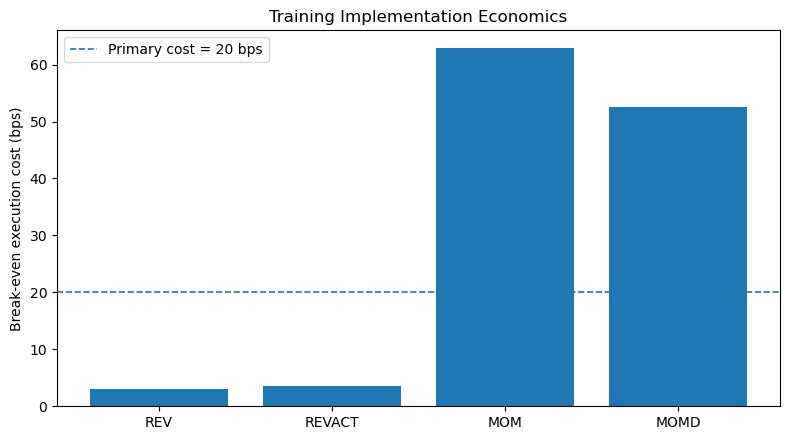

In [4]:
# Exact subsequent 4h returns for the training/runoff portfolio calendar.
training_return_times = portfolio_times[portfolio_times < VALIDATION_START]
start_prices = close_panel.reindex(training_return_times)
end_prices = close_panel.reindex(training_return_times + BAR_SIZE).copy()
end_prices.index = training_return_times
asset_forward_returns = end_prices / start_prices - 1.0


def build_execution_accounting(candidate, target_panel):
    available_full = target_panel.notna().any(axis=1)
    first_target_t = target_panel.index[available_full].min()
    last_target_t = target_panel.index[available_full].max()
    liquidation_t = last_target_t + BAR_SIZE

    assert liquidation_t <= VALIDATION_START

    accounting_times = pd.date_range(
        start=first_target_t,
        end=liquidation_t,
        freq=BAR_SIZE,
    )
    target = target_panel.reindex(accounting_times).copy()
    target_available = target.notna().any(axis=1)

    if target_available.any():
        assert target.loc[target_available].notna().all(axis=1).all()

    holdings = target.copy()
    holdings.loc[~target_available, :] = 0.0
    holdings.loc[liquidation_t, :] = 0.0
    holdings = holdings.astype(float)

    gross_exposure = holdings.abs().sum(axis=1)
    net_exposure = holdings.sum(axis=1)
    risk_bearing = gross_exposure > WEIGHT_TOL

    assert np.allclose(
        gross_exposure.loc[risk_bearing].to_numpy(),
        1.0,
        atol=1e-10,
    )
    assert net_exposure.abs().max() < 1e-9

    previous_holdings = holdings.shift(1).fillna(0.0)
    turnover = holdings.subtract(previous_holdings).abs().sum(axis=1)

    assert turnover.max() <= 2.0 + 1e-10
    assert np.isclose(turnover.loc[first_target_t], 1.0, atol=1e-10)
    assert np.isclose(turnover.loc[liquidation_t], 1.0, atol=1e-10)

    local_returns = asset_forward_returns.reindex(accounting_times)
    held_mask = holdings.abs() > WEIGHT_TOL
    missing_held_returns = (held_mask & local_returns.isna()).sum(axis=1).astype(int)

    gross_return = (holdings * local_returns.fillna(0.0)).sum(axis=1)
    gross_return = gross_return.where(missing_held_returns.eq(0))
    gross_return.loc[liquidation_t] = 0.0
    missing_held_returns.loc[liquidation_t] = 0

    result = pd.DataFrame(
        {
            "turnover": turnover,
            "gross_return": gross_return,
            "missing_held_returns": missing_held_returns,
        },
        index=accounting_times,
    )
    result["pnl_complete"] = result["gross_return"].notna()

    for cost_bps in COST_BPS_CASES:
        result[f"net_return_{cost_bps}bps"] = (
            result["gross_return"] - cost_bps * 1e-4 * result["turnover"]
        )

    return result


accounting_panels = {
    candidate: build_execution_accounting(candidate, weight_panels[candidate])
    for candidate in CANDIDATE_SPECS
}

summary_rows = []
for candidate, df in accounting_panels.items():
    complete = df["pnl_complete"]
    gross = df.loc[complete, "gross_return"]
    net20 = df.loc[complete, "net_return_20bps"]
    turnover = df.loc[complete, "turnover"]

    summary_rows.append(
        {
            "candidate": candidate,
            "mean_turnover": float(df["turnover"].mean()),
            "gross_sharpe": annualized_sharpe(gross),
            "net20_sharpe": annualized_sharpe(net20),
            "net20_compounded_return": compounded_return(net20),
            "break_even_bps": break_even_bps(gross, turnover),
        }
    )

training_summary = pd.DataFrame(summary_rows)

# Public-refactor reproduction gate against the frozen original Step-8 results.
frozen_training = {
    "reversal_baseline": {
        "gross_sharpe": 2.737051,
        "net20_sharpe": -15.388448,
        "break_even_bps": 3.017200,
    },
    "reversal_activity": {
        "gross_sharpe": 3.898054,
        "net20_sharpe": -18.376398,
        "break_even_bps": 3.494765,
    },
    "momentum_immediate": {
        "gross_sharpe": 2.256830,
        "net20_sharpe": 1.538926,
        "break_even_bps": 62.870866,
    },
    "momentum_delayed_1d": {
        "gross_sharpe": 2.104417,
        "net20_sharpe": 1.304363,
        "break_even_bps": 52.603865,
    },
}

for candidate, expected in frozen_training.items():
    row = training_summary.set_index("candidate").loc[candidate]
    for metric, value in expected.items():
        assert np.isclose(row[metric], value, atol=5e-6), (
            f"Training reproduction mismatch: {candidate} {metric}"
        )

display(training_summary.round(6))
print("Frozen Step-8 training-metric reproduction: PASS")

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = training_summary.set_index("candidate")
ax.bar(range(len(plot_df)), plot_df["break_even_bps"].to_numpy())
ax.axhline(20.0, linestyle="--", linewidth=1.2, label="Primary cost = 20 bps")
ax.set_xticks(range(len(plot_df)), ["REV", "REVACT", "MOM", "MOMD"])
ax.set_ylabel("Break-even execution cost (bps)")
ax.set_title("Training Implementation Economics")
ax.legend()
fig.tight_layout()
plt.show()

### Training implementation decision

The two reversal implementations have strong gross performance but extremely low break-even costs, so the apparent predictiveness does **not** survive realistic turnover.

A single predeclared execution-only check slowed REVACT refresh from 4h to 8h, 12h, and 24h without changing its signal. This reduces turnover but still does not make reversal viable at 20 bps.

The historical research also evaluated constrained reversal/momentum composites. The 50/50 and inverse-volatility variants failed after costs; the training max-net-Sharpe solution collapsed to an economically negligible reversal allocation and was not promoted.

Therefore only **MOM** and **MOMD** enter frozen 2023–2024 validation.

In [5]:
REFRESH_SPECS = {"4h": 1, "8h": 2, "12h": 3, "24h": 6}


def build_slow_reversal_target(original_panel, bars_per_refresh):
    refresh_hours = {
        1: {0, 4, 8, 12, 16, 20},
        2: {0, 8, 16},
        3: {0, 12},
        6: {0},
    }[bars_per_refresh]

    eligible_index = original_panel.index[
        original_panel.index <= TRAIN_FORMATION_END
    ]
    scheduled_times = eligible_index[eligible_index.hour.isin(refresh_hours)]
    last_schedule_t = scheduled_times.max()
    liquidation_t = last_schedule_t + bars_per_refresh * BAR_SIZE

    assert liquidation_t <= VALIDATION_START

    implementation_index = pd.date_range(
        start=scheduled_times.min(),
        end=liquidation_t,
        freq=BAR_SIZE,
    )

    held_targets = pd.DataFrame(
        0.0,
        index=implementation_index,
        columns=original_panel.columns,
        dtype=float,
    )
    current_target = pd.Series(0.0, index=original_panel.columns, dtype=float)
    scheduled_set = set(scheduled_times)

    for t in implementation_index:
        if t == liquidation_t:
            current_target = pd.Series(
                0.0, index=original_panel.columns, dtype=float
            )
        elif t in scheduled_set:
            row = original_panel.loc[t]
            if row.notna().any():
                assert row.notna().all()
                current_target = row.astype(float).copy()
            else:
                current_target = pd.Series(
                    0.0, index=original_panel.columns, dtype=float
                )

        held_targets.loc[t] = current_target.to_numpy()

    return held_targets


def account_carried_holdings(holdings):
    holdings = holdings.copy()
    assert holdings.notna().all().all()

    gross_exposure = holdings.abs().sum(axis=1)
    net_exposure = holdings.sum(axis=1)
    risk_bearing = gross_exposure > WEIGHT_TOL

    if risk_bearing.any():
        assert np.allclose(
            gross_exposure.loc[risk_bearing].to_numpy(),
            1.0,
            atol=1e-10,
        )
    assert net_exposure.abs().max() < 1e-9

    previous = holdings.shift(1).fillna(0.0)
    turnover = holdings.subtract(previous).abs().sum(axis=1)

    local_returns = asset_forward_returns.reindex(holdings.index)
    held_mask = holdings.abs() > WEIGHT_TOL
    missing = (held_mask & local_returns.isna()).sum(axis=1).astype(int)

    gross_return = (holdings * local_returns.fillna(0.0)).sum(axis=1)
    gross_return = gross_return.where(missing.eq(0))

    liquidation_t = holdings.index.max()
    gross_return.loc[liquidation_t] = 0.0
    missing.loc[liquidation_t] = 0

    result = pd.DataFrame(
        {
            "turnover": turnover,
            "gross_return": gross_return,
            "missing_held_returns": missing,
        },
        index=holdings.index,
    )
    result["pnl_complete"] = result["gross_return"].notna()
    result["net_return_20bps"] = (
        result["gross_return"] - 20e-4 * result["turnover"]
    )
    return result


redesign_rows = []
redesign_accounting = {}

for label, bars in REFRESH_SPECS.items():
    holdings = build_slow_reversal_target(
        weight_panels["reversal_activity"],
        bars,
    )
    df = account_carried_holdings(holdings)
    redesign_accounting[label] = df

    complete = df["pnl_complete"]
    gross = df.loc[complete, "gross_return"]
    net20 = df.loc[complete, "net_return_20bps"]
    to = df.loc[complete, "turnover"]

    redesign_rows.append(
        {
            "refresh": label,
            "mean_turnover": float(df["turnover"].mean()),
            "gross_sharpe": annualized_sharpe(gross),
            "net20_sharpe": annualized_sharpe(net20),
            "break_even_bps": break_even_bps(gross, to),
        }
    )

redesign_summary = pd.DataFrame(redesign_rows)

# The 4h carried-holdings implementation must reproduce the original REVACT path.
original = accounting_panels["reversal_activity"]
redesign_4h = redesign_accounting["4h"]
ordinary_common = original.index.intersection(redesign_4h.index)
ordinary_common = ordinary_common[ordinary_common < redesign_4h.index.max()]

assert (
    original.reindex(ordinary_common)["gross_return"]
    .subtract(redesign_4h.reindex(ordinary_common)["gross_return"])
    .abs()
    .dropna()
    .max()
    < 1e-12
)
assert (
    original.reindex(ordinary_common)["turnover"]
    .subtract(redesign_4h.reindex(ordinary_common)["turnover"])
    .abs()
    .dropna()
    .max()
    < 1e-12
)

frozen_redesign_be = {
    "4h": 3.494765,
    "8h": 2.106047,
    "12h": 4.716881,
    "24h": 7.855539,
}
for refresh, expected in frozen_redesign_be.items():
    actual = float(
        redesign_summary.set_index("refresh").loc[refresh, "break_even_bps"]
    )
    assert np.isclose(actual, expected, atol=5e-6)

display(redesign_summary.round(6))
print("REVACT refresh-cadence reproduction: PASS")
print("Reversal advances to validation:", False)
print("Validation candidates: momentum_immediate, momentum_delayed_1d")

,refresh,mean_turnover,gross_sharpe,net20_sharpe,break_even_bps
0,4h,1.375804,3.898054,-18.376398,3.494765
1,8h,0.668596,1.141222,-9.524806,2.106047
2,12h,0.442735,1.727923,-5.504961,4.716881
3,24h,0.221744,1.487397,-2.288695,7.855539


REVACT refresh-cadence reproduction: PASS
Reversal advances to validation: False
Validation candidates: momentum_immediate, momentum_delayed_1d


## 4. Frozen 2023–2024 validation

Before the original validation sample was opened, the implementation was frozen:

- candidates: MOM and MOMD only;
- signal formation: 2023-01-01 through 2024-12-25 exclusive;
- portfolio and cost accounting unchanged;
- primary comparison: timestamps where both strategies have complete P&L;
- primary cost: 20 bps per unit turnover;
- viability: **positive pooled 20-bps mean net return**;
- if neither candidate passes, validation is declared a failure;
- 2025+ remains closed.

The public refactor above first reproduces the frozen training metrics. The following section then reconstructs the validation period under the same implementation.

In [7]:
# Separate validation load with a strict final-test firewall.
validation_close_series = []

for symbol in research_symbols:
    path = PROCESSED_DIR / f"{symbol}_4h.parquet"
    if not path.exists():
        raise FileNotFoundError(f"Missing required processed file: {path}")

    df = pd.read_parquet(
        path,
        columns=["open_time", "close"],
    ).copy()

    df["open_time"] = pd.to_datetime(df["open_time"], utc=True)
    df["timestamp"] = df["open_time"] + BAR_SIZE
    df = (
        df.loc[df["timestamp"] < FINAL_TEST_START, ["timestamp", "close"]]
        .drop_duplicates("timestamp")
        .sort_values("timestamp")
    )

    validation_close_series.append(
        df.set_index("timestamp")["close"].astype(float).rename(symbol)
    )

validation_close_panel = (
    pd.concat(validation_close_series, axis=1)
    .sort_index()
    .reindex(columns=research_symbols)
)

assert validation_close_panel.index.max() < FINAL_TEST_START

VALIDATION_CANDIDATES = [
    "momentum_immediate",
    "momentum_delayed_1d",
]

validation_return_3d = exact_endpoint_return(
    validation_close_panel,
    pd.Timedelta(days=3),
)

validation_times = validation_close_panel.index[
    (validation_close_panel.index >= VALIDATION_START)
    & (validation_close_panel.index < VALIDATION_FORMATION_END_EXCLUSIVE)
]
validation_times = pd.DatetimeIndex(
    [t for t in validation_times if month_start(t) in membership_by_month]
)

assert validation_times.min() == VALIDATION_START
assert validation_times.max() == pd.Timestamp(
    "2024-12-24 20:00:00",
    tz="UTC",
)
assert len(validation_times) == 4344

source_rank_start = VALIDATION_START - MOMENTUM_DELAY
source_rank_times = validation_close_panel.index[
    (validation_close_panel.index >= source_rank_start)
    & (validation_close_panel.index <= validation_times.max())
]
source_rank_times = pd.DatetimeIndex(
    [t for t in source_rank_times if month_start(t) in membership_by_month]
)

validation_price_rank_3d = pd.DataFrame(
    np.nan,
    index=source_rank_times,
    columns=research_symbols,
    dtype=float,
)

for t in source_rank_times:
    members = list(membership_by_month[month_start(t)])
    raw = validation_return_3d.loc[t, members].dropna()
    if len(raw) >= MIN_ASSETS:
        ranked = centered_rank(raw)
        validation_price_rank_3d.loc[t, ranked.index] = ranked.values

validation_signals = {
    candidate: pd.DataFrame(
        np.nan,
        index=validation_times,
        columns=research_symbols,
        dtype=float,
    )
    for candidate in VALIDATION_CANDIDATES
}

for t in validation_times:
    members = list(membership_by_month[month_start(t)])

    current = validation_price_rank_3d.loc[t, members].dropna()
    if len(current) >= MIN_ASSETS:
        validation_signals["momentum_immediate"].loc[
            t, current.index
        ] = current.values

    source_t = t - MOMENTUM_DELAY
    if source_t in validation_price_rank_3d.index:
        old = validation_price_rank_3d.loc[source_t, members].dropna()
        if len(old) >= MIN_ASSETS:
            validation_signals["momentum_delayed_1d"].loc[
                t, old.index
            ] = old.values

coverage_rows = []
for candidate, panel in validation_signals.items():
    counts = panel.notna().sum(axis=1)
    usable = counts >= MIN_ASSETS
    coverage_rows.append(
        {
            "candidate": candidate,
            "decision_timestamps": len(panel),
            "usable_signal_timestamps": int(usable.sum()),
            "first_usable": panel.index[usable].min(),
            "last_usable": panel.index[usable].max(),
            "min_valid_assets": int(counts.loc[usable].min()),
            "max_valid_assets": int(counts.loc[usable].max()),
        }
    )

validation_coverage = pd.DataFrame(coverage_rows)

expected_validation_usable = {
    "momentum_immediate": 4344,
    "momentum_delayed_1d": 4302,
}
for candidate, expected in expected_validation_usable.items():
    actual = int(
        validation_coverage.set_index("candidate").loc[
            candidate, "usable_signal_timestamps"
        ]
    )
    assert actual == expected

validation_max_vintage_diff = 0.0
validation_vintage_checks = 0
for t, delayed_row in validation_signals["momentum_delayed_1d"].iterrows():
    valid = delayed_row.notna()
    if not valid.any():
        continue
    source_row = validation_price_rank_3d.loc[t - MOMENTUM_DELAY]
    diff = (delayed_row.loc[valid] - source_row.loc[valid]).abs()
    validation_max_vintage_diff = max(
        validation_max_vintage_diff,
        float(diff.max()),
    )
    validation_vintage_checks += len(diff)

assert validation_vintage_checks > 0
assert validation_max_vintage_diff < 1e-12

validation_entry_weights = {
    candidate: score_to_entry_weights(validation_signals[candidate])
    for candidate in VALIDATION_CANDIDATES
}

validation_portfolio_times = pd.date_range(
    start=VALIDATION_START,
    end=VALIDATION_ACCOUNTING_END - BAR_SIZE,
    freq=BAR_SIZE,
)

validation_weights = {
    candidate: build_live_portfolio(
        validation_entry_weights[candidate],
        CANDIDATE_SPECS[candidate]["holding_period"],
        validation_portfolio_times,
    )
    for candidate in VALIDATION_CANDIDATES
}

validation_start_prices = validation_close_panel.reindex(validation_portfolio_times)
validation_end_index = validation_portfolio_times + BAR_SIZE

assert validation_end_index.max() <= VALIDATION_ACCOUNTING_END
assert validation_end_index.max() < FINAL_TEST_START

validation_end_prices = validation_close_panel.reindex(validation_end_index).copy()
validation_end_prices.index = validation_portfolio_times
validation_asset_forward_returns = (
    validation_end_prices / validation_start_prices - 1.0
)

validation_accounting_times = pd.date_range(
    start=VALIDATION_START,
    end=VALIDATION_ACCOUNTING_END,
    freq=BAR_SIZE,
)


def build_validation_accounting(target_panel):
    target = target_panel.reindex(validation_accounting_times).copy()
    target_available = target.notna().any(axis=1)

    holdings = target.copy()
    holdings.loc[~target_available, :] = 0.0
    holdings = holdings.fillna(0.0).astype(float)

    gross_exposure = holdings.abs().sum(axis=1)
    net_exposure = holdings.sum(axis=1)
    risk_bearing = gross_exposure > WEIGHT_TOL

    if risk_bearing.any():
        assert np.allclose(
            gross_exposure.loc[risk_bearing].to_numpy(),
            1.0,
            atol=1e-10,
        )
    assert net_exposure.abs().max() < 1e-9

    previous = holdings.shift(1).fillna(0.0)
    turnover = holdings.subtract(previous).abs().sum(axis=1)
    assert turnover.max() <= 2.0 + 1e-10

    first_risky_t = risk_bearing[risk_bearing].index.min()
    assert np.isclose(turnover.loc[first_risky_t], 1.0, atol=1e-10)

    local_returns = validation_asset_forward_returns.reindex(
        validation_accounting_times
    )
    held_mask = holdings.abs() > WEIGHT_TOL
    missing = (held_mask & local_returns.isna()).sum(axis=1).astype(int)

    gross_return = (holdings * local_returns.fillna(0.0)).sum(axis=1)
    gross_return = gross_return.where(missing.eq(0))
    cash_mask = ~risk_bearing
    gross_return.loc[cash_mask & missing.eq(0)] = 0.0

    result = pd.DataFrame(
        {
            "turnover": turnover,
            "gross_return": gross_return,
            "missing_held_returns": missing,
        },
        index=validation_accounting_times,
    )
    result["pnl_complete"] = result["gross_return"].notna()

    for cost_bps in COST_BPS_CASES:
        result[f"net_return_{cost_bps}bps"] = (
            result["gross_return"] - cost_bps * 1e-4 * result["turnover"]
        )

    return result


validation_accounting = {
    candidate: build_validation_accounting(validation_weights[candidate])
    for candidate in VALIDATION_CANDIDATES
}

common_complete = (
    validation_accounting["momentum_immediate"]["pnl_complete"]
    & validation_accounting["momentum_delayed_1d"]["pnl_complete"]
)
common_validation_times = validation_accounting_times[
    common_complete.to_numpy()
]

assert len(common_validation_times) == 4386
assert common_validation_times.min() == VALIDATION_START
assert common_validation_times.max() == VALIDATION_ACCOUNTING_END

validation_rows = []
yearly_rows = []

for candidate in VALIDATION_CANDIDATES:
    df = validation_accounting[candidate].loc[common_validation_times].copy()
    gross = df["gross_return"]
    net20 = df["net_return_20bps"]

    validation_rows.append(
        {
            "candidate": candidate,
            "common_periods": len(df),
            "mean_turnover": float(df["turnover"].mean()),
            "mean_gross_return": float(gross.mean()),
            "gross_sharpe": annualized_sharpe(gross),
            "mean_net_return_20bps": float(net20.mean()),
            "net_sharpe_7bps": annualized_sharpe(df["net_return_7bps"]),
            "net_sharpe_20bps": annualized_sharpe(net20),
            "net_sharpe_40bps": annualized_sharpe(df["net_return_40bps"]),
            "net_compounded_return_20bps": compounded_return(net20),
            "break_even_bps": break_even_bps(gross, df["turnover"]),
        }
    )

    for year in [2023, 2024]:
        year_df = df.loc[df.index.year == year]
        year_net20 = year_df["net_return_20bps"]
        yearly_rows.append(
            {
                "candidate": candidate,
                "year": year,
                "periods": len(year_df),
                "mean_net_return_20bps": float(year_net20.mean()),
                "net_sharpe_20bps": annualized_sharpe(year_net20),
                "net_compounded_return_20bps": compounded_return(year_net20),
                "mean_turnover": float(year_df["turnover"].mean()),
            }
        )

validation_summary = pd.DataFrame(validation_rows)
validation_yearly = pd.DataFrame(yearly_rows)

# Frozen public-refactor regression tests.
frozen_validation = {
    "momentum_immediate": {
        "mean_turnover": 0.062069,
        "gross_sharpe": 0.122314,
        "mean_net_return_20bps": -0.000110,
        "net_sharpe_20bps": -0.984266,
        "break_even_bps": 2.210610,
    },
    "momentum_delayed_1d": {
        "mean_turnover": 0.067221,
        "gross_sharpe": -0.097764,
        "mean_net_return_20bps": -0.000145,
        "net_sharpe_20bps": -1.324775,
        "break_even_bps": -1.593617,
    },
}

indexed_validation = validation_summary.set_index("candidate")
for candidate, expected in frozen_validation.items():
    for metric, value in expected.items():
        assert np.isclose(
            float(indexed_validation.loc[candidate, metric]),
            value,
            atol=5e-6,
        ), f"Validation reproduction mismatch: {candidate} {metric}"

selection_table = validation_summary[
    ["candidate", "mean_net_return_20bps", "net_sharpe_20bps"]
].copy()
selection_table["passes_20bps_viability"] = (
    selection_table["mean_net_return_20bps"] > 0
)

passing = selection_table.loc[selection_table["passes_20bps_viability"]]
assert len(passing) == 0
validation_decision = "VALIDATION_FAILURE"

print("Latest validation price timestamp admitted:", validation_close_panel.index.max())
print("2025+ admitted:", bool(validation_close_panel.index.max() >= FINAL_TEST_START))
print("Validation formation timestamps:", len(validation_times))
print("Maximum validation MOMD vintage difference:", f"{validation_max_vintage_diff:.3e}")
print("\nStructural coverage:")
display(validation_coverage)
print("\nPooled validation results:")
display(validation_summary.round(6))
print("\nYear-by-year supporting results:")
display(validation_yearly.round(6))
print("\nPredeclared selection table:")
display(selection_table.round(6))
print("\nVALIDATION DECISION:", validation_decision)
print("Frozen validation-result reproduction: PASS")

Latest validation price timestamp admitted: 2024-12-31 20:00:00+00:00
2025+ admitted: False
Validation formation timestamps: 4344
Maximum validation MOMD vintage difference: 0.000e+00

Structural coverage:


,candidate,decision_timestamps,usable_signal_timestamps,first_usable,last_usable,min_valid_assets,max_valid_assets
0,momentum_immediate,4344,4344,2023-01-01 00:00:00+00:00,2024-12-24 20:00:00+00:00,25,25
1,momentum_delayed_1d,4344,4302,2023-01-01 00:00:00+00:00,2024-12-24 20:00:00+00:00,20,25



Pooled validation results:


,candidate,common_periods,mean_turnover,mean_gross_return,gross_sharpe,mean_net_return_20bps,net_sharpe_7bps,net_sharpe_20bps,net_sharpe_40bps,net_compounded_return_20bps,break_even_bps
0,momentum_immediate,4386,0.062069,0.000014,0.122314,-0.000110,-0.264999,-0.984266,-2.090574,-0.420031,2.210610
1,momentum_delayed_1d,4386,0.067221,-0.000011,-0.097764,-0.000145,-0.527212,-1.324775,-2.551613,-0.500614,-1.593617



Year-by-year supporting results:


,candidate,year,periods,mean_net_return_20bps,net_sharpe_20bps,net_compounded_return_20bps,mean_turnover
0,momentum_immediate,2023,2190,-0.000090,-0.914507,-0.198518,0.061106
1,momentum_immediate,2024,2196,-0.000130,-1.050804,-0.276379,0.063030
2,momentum_delayed_1d,2023,2190,-0.000133,-1.375637,-0.268422,0.066601
3,momentum_delayed_1d,2024,2196,-0.000158,-1.299834,-0.317385,0.067839



Predeclared selection table:


,candidate,mean_net_return_20bps,net_sharpe_20bps,passes_20bps_viability
0,momentum_immediate,-0.000110,-0.984266,False
1,momentum_delayed_1d,-0.000145,-1.324775,False



VALIDATION DECISION: VALIDATION_FAILURE
Frozen validation-result reproduction: PASS


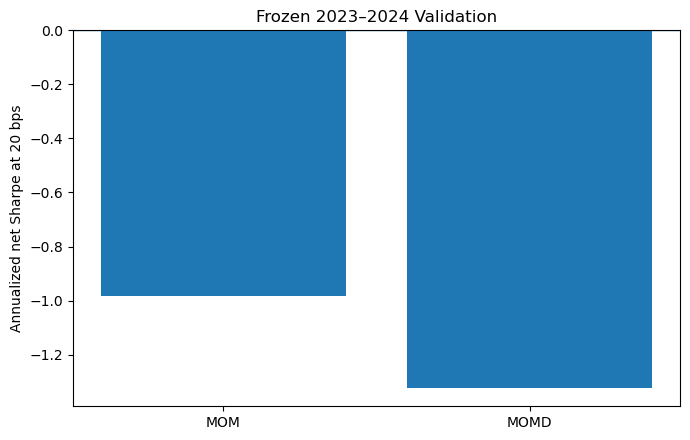

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_df = validation_summary.set_index("candidate")
ax.bar(
    [0, 1],
    plot_df.loc[
        ["momentum_immediate", "momentum_delayed_1d"],
        "net_sharpe_20bps",
    ].to_numpy(),
)
ax.axhline(0.0, linewidth=1.0)
ax.set_xticks([0, 1], ["MOM", "MOMD"])
ax.set_ylabel("Annualized net Sharpe at 20 bps")
ax.set_title("Frozen 2023–2024 Validation")
fig.tight_layout()
plt.show()

## 5. Conclusion — the initial strategy failed validation

Both frozen momentum implementations fail the predeclared 2023–2024 viability rule:

- MOM has slightly positive gross performance but becomes economically negative at 20 bps;
- MOMD is negative even before the primary cost assumption is applied;
- both are negative in both 2023 and 2024 after 20-bps costs.

The correct research decision at this checkpoint was therefore **VALIDATION FAILURE**.

This result is preserved in the final project. The strategy is not retroactively declared successful because a later redesign works. At this point in the historical research process, 2025+ remained closed and no parameter rescue was permitted.

The next public notebook begins only after this failure: it diagnoses what broke using pre-2025 information, separates reversal from a different continuation architecture, and freezes the later finalists before the untouched final holdout is opened.